# 01 — Data Loading & Sanity Check
Loads the PaySim dataset and runs basic validation before any feature engineering.

In [ ]:
%pip install --quiet pandas matplotlib seaborn

In [1]:
import os
import time

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)
sns.set_theme(style='whitegrid', palette='muted')

print('Libraries loaded ✅')

Libraries loaded ✅


In [2]:
DATA_PATH    = "../data/raw/PS_20174392719_1491204439457_log.csv"
SAMPLE_N     = 100_000
RANDOM_STATE = 42

print(f"DATA_PATH  : {DATA_PATH}")
print(f"File exists: {os.path.exists(DATA_PATH)}")

DATA_PATH  : ../data/raw/PS_20174392719_1491204439457_log.csv
File exists: True


In [3]:
print(f"Loading dataset: {DATA_PATH}")
t0 = time.time()
df_raw = pd.read_csv(DATA_PATH).sample(SAMPLE_N, random_state=RANDOM_STATE).reset_index(drop=True)
print(f"✓ Loaded {len(df_raw):,} rows in {time.time() - t0:.1f}s")

df_raw.head()

Loading dataset: ../data/raw/PS_20174392719_1491204439457_log.csv
✓ Loaded 100,000 rows in 0.6s


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,45,TRANSFER,"422,698.86",C1403836777,"20,502.00",0.00,C355530332,"1,548,167.23","1,970,866.09",0,0
1,10,CASH_IN,"285,423.14",C1223059230,510.00,"285,933.14",C708232604,561.00,0.00,0,0
2,23,CASH_IN,"176,371.13",C2047243429,"2,227,768.61","2,404,139.74",C1614837211,"2,471,996.98","2,295,625.85",0,0
3,20,CASH_OUT,"283,759.53",C813860567,"6,231.00",0.00,C603023442,"1,397,807.89","1,681,567.41",0,0
4,9,CASH_OUT,"262,268.28",C204225557,"104,675.00",0.00,C426784026,"76,376.58","1,674,917.08",0,0


In [4]:
print("Shape :", df_raw.shape)
print("\nDtypes:")
print(df_raw.dtypes)
print("\nMissing values:")
print(df_raw.isnull().sum())

Shape : (100000, 11)

Dtypes:
step                int64
type                  str
amount            float64
nameOrig              str
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest              str
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object

Missing values:
step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64


In [5]:
df_raw.describe(include='all')

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,"100,000.00",100000,"100,000.00",100000,"100,000.00","100,000.00",100000,"100,000.00","100,000.00","100,000.00","100,000.00"
unique,NaN,5,NaN,99997,NaN,NaN,73083,NaN,NaN,NaN,NaN
top,NaN,CASH_OUT,NaN,C576266066,NaN,NaN,C665576141,NaN,NaN,NaN,NaN
freq,NaN,36191,NaN,2,NaN,NaN,13,NaN,NaN,NaN,NaN
mean,25.13,NaN,"160,322.95",NaN,"875,537.02","895,886.18",NaN,"975,453.08","1,114,738.30",0.00,0.00
std,12.65,NaN,"261,265.46",NaN,"2,955,205.09","2,992,286.05",NaN,"2,265,445.40","2,387,748.81",0.02,0.00
min,1.00,NaN,0.30,NaN,0.00,0.00,NaN,0.00,0.00,0.00,0.00
25%,14.00,NaN,"12,655.88",NaN,0.00,0.00,NaN,0.00,0.00,0.00,0.00
50%,20.00,NaN,"79,142.05",NaN,"15,994.00",0.00,NaN,"130,949.58","227,637.51",0.00,0.00
75%,38.00,NaN,"215,935.78",NaN,"141,939.05","180,831.79",NaN,"917,526.49","1,158,190.32",0.00,0.00


In [6]:
fraud_count = df_raw['isFraud'].sum()
total       = len(df_raw)
print(f"Fraud cases : {fraud_count:,} / {total:,}  ({fraud_count/total*100:.3f}%)")
print(f"\nFraud by transaction type:")
print(df_raw.groupby('type')['isFraud'].agg(['sum','mean']).rename(columns={'sum':'fraud_n','mean':'fraud_rate'}))

Fraud cases : 52 / 100,000  (0.052%)

Fraud by transaction type:
          fraud_n  fraud_rate
type                         
CASH_IN         0        0.00
CASH_OUT       29        0.00
DEBIT           0        0.00
PAYMENT         0        0.00
TRANSFER       23        0.00


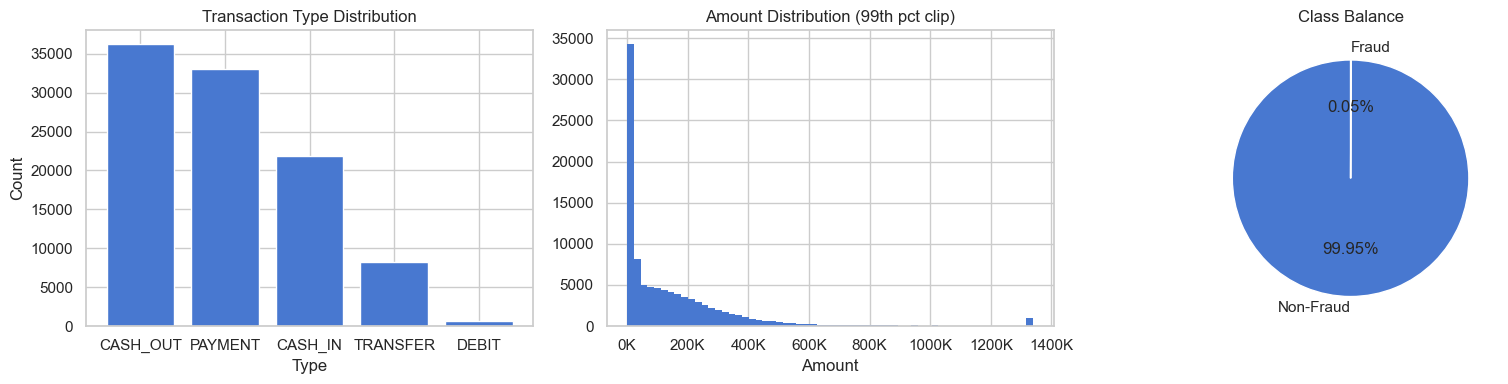

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Transaction type distribution
type_counts = df_raw['type'].value_counts()
axes[0].bar(type_counts.index, type_counts.values)
axes[0].set_title('Transaction Type Distribution')
axes[0].set_xlabel('Type')
axes[0].set_ylabel('Count')

# Amount distribution (log scale)
axes[1].hist(df_raw['amount'].clip(upper=df_raw['amount'].quantile(0.99)), bins=60, edgecolor='none')
axes[1].set_title('Amount Distribution (99th pct clip)')
axes[1].set_xlabel('Amount')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))

# Fraud vs non-fraud
labels = ['Non-Fraud', 'Fraud']
sizes  = df_raw['isFraud'].value_counts().sort_index().values
axes[2].pie(sizes, labels=labels, autopct='%1.2f%%', startangle=90)
axes[2].set_title('Class Balance')

plt.tight_layout()
plt.show()

In [8]:
out_path = "../data/raw/sampled_100k.csv"
df_raw.to_csv(out_path, index=False)
print(f"✓ Saved working sample → {out_path}  |  shape: {df_raw.shape}")

✓ Saved working sample → ../data/raw/sampled_100k.csv  |  shape: (100000, 11)
